In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import os
import sys
sys.path.append('..')
from hypso.hypso2 import Hypso2
from hypso.hypso1 import Hypso1

# Load HYPSO-1 and HYPSO-2 datacubes

In [7]:
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'

In [8]:
satobj_h1 = Hypso1(path=l1a_nc_file_h1, verbose=True)
satobj_h2 = Hypso2(path=l1a_nc_file_h2, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] No georeferencing .points file provided. Skipping georeferencing.
[INFO] Loading L1a capture lacrau_2024-12-26T11-15-54Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide


In [9]:
l1a_cube_h1 = satobj_h1.get_l1b_cube()
l1a_cube_h2 = satobj_h2.get_l1b_cube()

In [11]:
satobj_h1.generate_l1b_cube()
satobj_h2.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...
[INFO] Running calibration routines...
[INFO] Running radiometric calibration...


In [13]:
calibrated_cube_h1 = satobj_h1.get_l1b_cube()
calibrated_cube_h2 = satobj_h2.get_l1b_cube()

(np.float64(-0.5), np.float64(1091.5), np.float64(597.5), np.float64(-0.5))

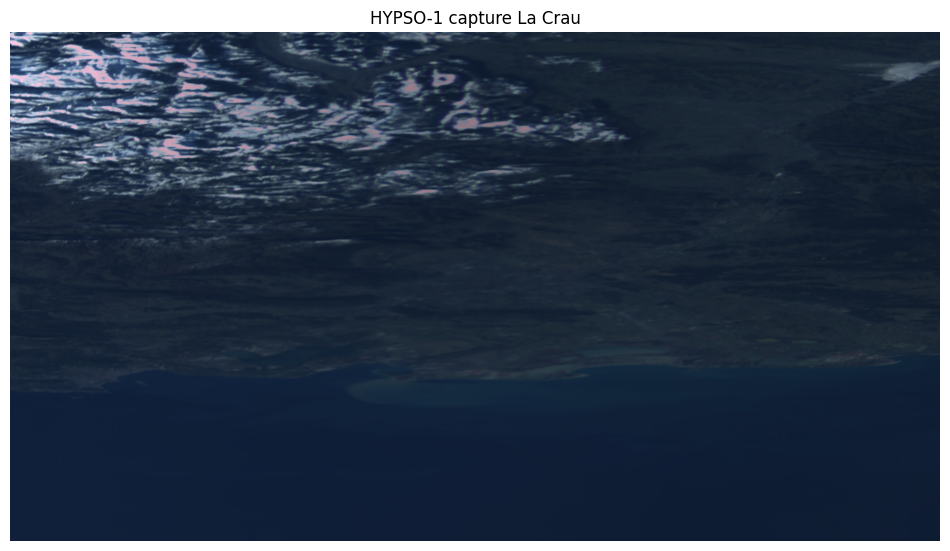

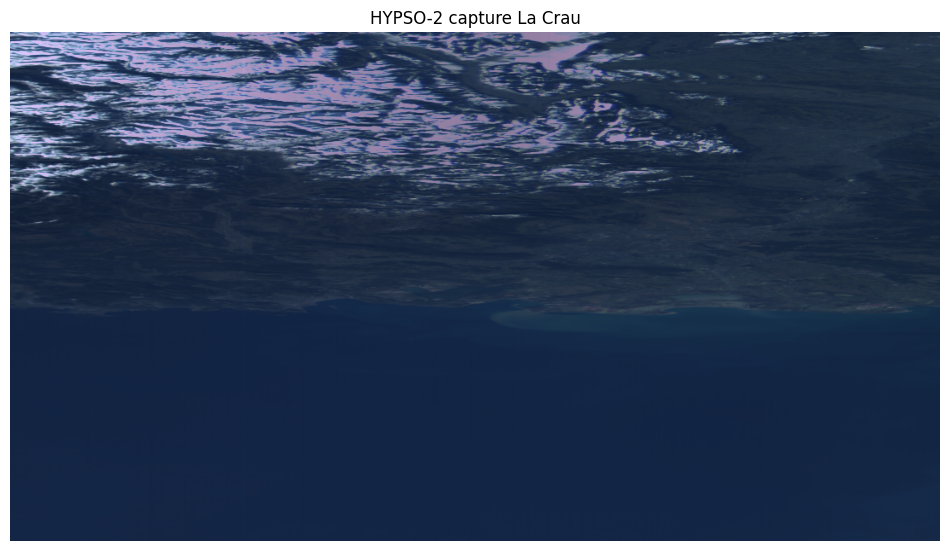

In [18]:

#R:630nm, G:550nm, B:480nm
# Red, Green, Blue, Alpha
red_wl = 630
green_wl = 550
blue_wl = 480

red_idx =   satobj_h1.get_closest_wavelength_index(red_wl)
green_idx = satobj_h1.get_closest_wavelength_index(green_wl)
blue_idx =  satobj_h1.get_closest_wavelength_index(blue_wl)


composite_h1 = (255*calibrated_cube_h1[:,:,[red_idx, green_idx, blue_idx]]/calibrated_cube_h1[:,:,[red_idx, green_idx, blue_idx]].max()).astype(int)
composite_h2 = (255*calibrated_cube_h2[:,:,[red_idx, green_idx, blue_idx]]/calibrated_cube_h2[:,:,[red_idx, green_idx, blue_idx]].max()).astype(int)
plt.figure(figsize=(12,12))
plt.title('HYPSO-1 capture La Crau')
plt.imshow(composite_h1)
plt.axis('off')
plt.figure(figsize=(12,12))
plt.title('HYPSO-2 capture La Crau')
plt.imshow(composite_h2)
plt.axis('off')

# Test ToA reflectance

In [2]:
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'

In [3]:
satobj_h2 = Hypso2(path=l1a_nc_file_h2, verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T11-15-54Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide


In [4]:
satobj_h2.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...


In [5]:
satobj_h2.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 30
Quaternion samples: 30
ADCS time range:         -0.000000 to          0.000000
Frame time range: 1735211754.537797 to 1735211829.162797
ERROR: Frame timestamps end later than ADCS data!


SystemExit: -1

/home/ariaa/HYPSO test code/hypso-package/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [6]:
satobj_h2.generate_toa_reflectance()

toa_rrs_cube = satobj_h2.get_toa_reflectance()

TypeError: loop of ufunc does not support argument 0 of type NoneType which has no callable radians method

In [ ]:
wavelengths_h2 = satobj_h2.wavelengths[satobj_h2.x_start:satobj_h2.x_stop].reshape(-1, satobj_h2.bin_factor).mean(axis=1).reshape(-1)
x_gsp_h2, y_gsp_h2 = 305, 625

plt.subplot(2,1,1)
plt.title('HYPSO-2 l1b La Crau 26.12.24 11:16')
plt.xlabel('Band')
plt.ylabel('ToA Radiance')
plt.ylim(0, 65)
plt.plot(wavelengths_h2[7:], toa_rrs_cube[x_gsp_h2, y_gsp_h2, 7:]) # wavelength mapping is not correct ...
plt.grid()
# plt.plot(np.arange(450, 800, (800 - 450 ) / 120), calibrated_cube[305, 660, :]) # wavelength mapping is not correct ...

# plt.subplot(2,1,2)
# plt.title('ToA RadCalNet reflectance La Crau 26.12.24 11:00')
# plt.xlabel('Wavelength [nm]')
# plt.ylabel('ToA Reflectance')
# plt.grid()
# plt.plot(ToA_reflectance[:40,0], ToA_reflectance[:40, 4])
# plt.tight_layout()

# Test georeferencing

In [72]:
from netCDF4 import Dataset

# specify the path to your netCDF file
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-l1a.nc'

# open the NetCDF file
nc_file_h1 = Dataset(l1a_nc_file_h1, mode='r')
nc_file_h2 = Dataset(l1a_nc_file_h2, mode='r')

# print timestamps min and max values
print('min and max timestamp h1 capture: ', nc_file_h1.groups['metadata'].groups['adcs'].variables['timestamps'][:].min(), nc_file_h1.groups['metadata'].groups['adcs'].variables['timestamps'][:].max()) # seems like h2 is missing a good bit of the adcs metadata
print('min and max timestamp h2 capture: ', nc_file_h2.groups['metadata'].groups['adcs'].variables['timestamps'][:].min(), nc_file_h2.groups['metadata'].groups['adcs'].variables['timestamps'][:].max()) # seems like h2 is missing a good bit of the adcs metadata

# close the file
nc_file_h1.close()
nc_file_h2.close()

min and max timestamp h1 capture:  1735207980.0 1735208940.0
min and max timestamp h2 capture:  -8.032017755852548e+269 4.55348748566849e+301


In [75]:
l1a_nc_file_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-l1a.nc'
points_h1 = '/home/ariaa/HYPSO test code/data/h1_lacrau_2024-12-26T10-24-27/lacrau_2024-12-26T10-24-27Z-scaled_test.points'
l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-l1a.nc'
points_h2 = '/home/ariaa/HYPSO test code/data/h2_lacrau_2024-12-26T11-15-54/lacrau_2024-12-26T11-15-54Z-scaled_test.points'

# try h2 capture with higher adcs sampling rate
# l1a_nc_file_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-l1a.nc'
# points_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-scaled.points'
# points_h2 = '/home/ariaa/HYPSO test code/data/h2_gulfofcalifornia_2025-01-29T18-22-53Z/gulfofcalifornia_2025-01-29T18-22-53Z-scaled_mercator.points'

In [42]:
# use h1 object just to get the wavelengths
satobj_h1 = Hypso1(path=l1a_nc_file_h1, points_path=points_h1,  verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T10-24-27Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] Running georeferencing...
No image mode provided. Detected image mode: bin3
[INFO] Using UTM map: WGS 84 / UTM zone 31N EPSG: 32631


In [4]:
satobj_h1.generate_l1b_cube()

[INFO] Running calibration routines...
[INFO] Running radiometric calibration...
[INFO] Running smile correction...
[INFO] Running destriping correction...


In [5]:
l1a_scene_h1 = satobj_h1.get_l1a_satpy_scene()

In [76]:
satobj_h2 = Hypso1(path=l1a_nc_file_h2, points_path=points_h2,  verbose=True)

[INFO] Loading L1a capture lacrau_2024-12-26T11-15-54Z
[INFO] Capture spatial dimensions: (598, 1092)
[INFO] Capture capture type: wide
[INFO] Running georeferencing...
No image mode provided. Detected image mode: bin3


/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:65: RuntimeWarning: invalid value encountered in scalar divide
  quat[0] /= mag
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:66: RuntimeWarning: invalid value encountered in scalar divide
  quat[1] /= mag
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:67: RuntimeWarning: invalid value encountered in scalar divide
  quat[2] /= mag
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:68: RuntimeWarning: invalid value encountered in scalar divide
  quat[3] /= mag
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:97: RuntimeWarning: invalid value encountered in scalar divide
  cos_vel_angle = (vel[0]*body_x_teme[0] + vel[1]*body_x_teme[1] + vel[2]*body_x_teme[2]) / vellen
/home/ariaa/HYPSO test code/hypso-package/demo/../hypso/georeference/utils.py:64: RuntimeWarning: overflow encountered in scalar

[INFO] Using UTM map: WGS 84 / UTM zone 32N EPSG: 32632


In [77]:
l1a_scene_h2 = satobj_h2.get_l1a_satpy_scene()

## test if .points file worked

In [78]:
satobj_h2.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 30
Quaternion samples: 30
ADCS time range:         -0.000000 to          0.000000
Frame time range: 1735211754.537797 to 1735211829.162797
ERROR: Frame timestamps end later than ADCS data!


SystemExit: -1

/home/ariaa/HYPSO test code/hypso-package/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [47]:
satobj_h2.generate_geometry()

[INFO] Running geometry computation...
ECI position samples: 516
Quaternion samples: 516
ADCS time range:          0.000000 to 80298889434831886706452504047968031140558278030591842303532165512756344347344002300459719355226705614499244934281990544664855074222227146571016264052557148126990905464293750704624341899098424521364450139445304063949513961315943185692634748126551083933126975972281123917220128185384960.000000
Frame time range: 1738174973.479410 to 1738175048.104410
3 sample(s) inside frame time range
Interpolating 598 frames
Spatial dimensions: 598 frames/lines, 1092 pixels/samples
Computing pixel latitude and longitude coordinates...
[ERROR] At least one pixel was pointing beyond the earth's horizon!


SystemExit: 2

/home/ariaa/HYPSO test code/hypso-package/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [10]:
satobj_h1.generate_toa_reflectance()

toa_rrs_cube = satobj_h1.get_toa_reflectance()

In [11]:
toa_rrs_cube

<xarray.DataArray (y: 598, x: 1092, band: 120)> Size: 627MB
array([[[0.        , 0.        , 0.        , ..., 0.20794072,
         0.53465836, 0.75250566],
        [0.        , 0.        , 0.        , ..., 0.21470591,
         0.53724299, 0.75713378],
        [0.        , 0.        , 0.        , ..., 0.22037745,
         0.55047942, 0.78039585],
        ...,
        [0.        , 0.        , 0.        , ..., 0.49206751,
         1.22724982, 1.67934652],
        [0.        , 0.        , 0.        , ..., 0.50696829,
         1.2286582 , 1.58560135],
        [0.        , 0.        , 0.        , ..., 0.51188718,
         1.27503336, 1.8488262 ]],

       [[0.        , 0.        , 0.        , ..., 0.22187056,
         0.55480504, 0.8062194 ],
        [0.        , 0.        , 0.        , ..., 0.22759249,
         0.54483045, 0.80791149],
        [0.        , 0.        , 0.        , ..., 0.22048709,
         0.55553698, 0.78067034],
...
        [0.        , 0.        , 0.        , ..., 0.05587178,
         0.15844726, 0.21877597],
        [0.        , 0.        , 0.        , ..., 0.05676658,
         0.16016777, 0.27902401],
        [0.        , 0.        , 0.        , ..., 0.05671493,
         0.16415927, 0.25836932]],

       [[0.        , 0.        , 0.        , ..., 0.04867301,
         0.13363003, 0.20679411],
        [0.        , 0.        , 0.        , ..., 0.04797912,
         0.13103013, 0.22189173],
        [0.        , 0.        , 0.        , ..., 0.04908689,
         0.12911378, 0.22653374],
        ...,
        [0.        , 0.        , 0.        , ..., 0.05560681,
         0.16460046, 0.24733421],
        [0.        , 0.        , 0.        , ..., 0.05638584,
         0.16258528, 0.2640177 ],
        [0.        , 0.        , 0.        , ..., 0.05502087,
         0.16077439, 0.283522  ]]], shape=(598, 1092, 120))
Dimensions without coordinates: y, x, band
Attributes:
    level:        toa_refl
    units:        sr^{-1}
    description:  TOA Reflectance (R)
    correction:   None

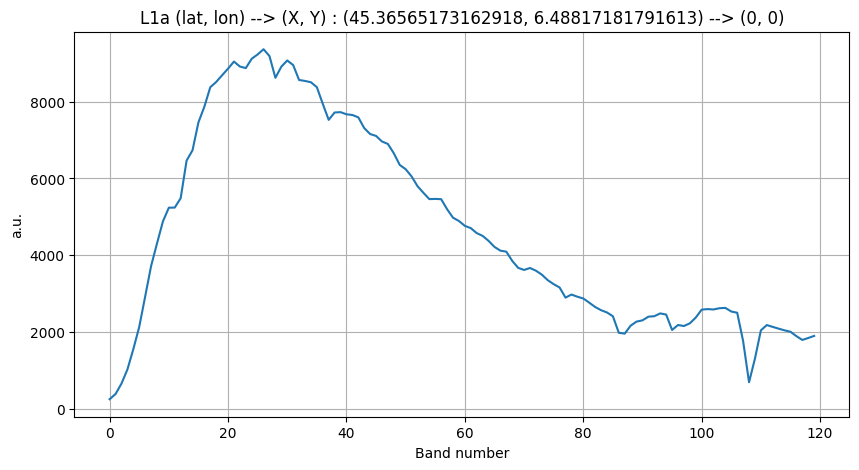

In [31]:
lat =  satobj_h1.latitudes[0, 0] #[200,500]
lon = satobj_h1.longitudes[0, 0] #[200,500]

l1a_spectrum = satobj_h1.get_l1a_spectrum(latitude=lat, longitude=lon)

satobj_h1.plot_l1a_spectrum(latitude=lat, longitude=lon)


## Load area definition

In [8]:
from pyresample import load_area
area_def = load_area("./lacrau_demo.yaml")

## Resample capture to area definition

In [ ]:
resampled_l1a_scene_h1 = l1a_scene_h1.resample(area_def, resampler='bilinear', fill_value=np.nan)

## Create resampled RGB composite from L1A cube

In [20]:
import satpy
from satpy.composites import GenericCompositor
from satpy.writers import to_image

# RGB Hypso image
compositor = GenericCompositor("rgb")

#R:630nm, G:550nm, B:480nm
# Red, Green, Blue, Alpha
red_wl = 630
green_wl = 550
blue_wl = 480

red_idx =   satobj_h1.get_closest_wavelength_index(red_wl)
green_idx = satobj_h1.get_closest_wavelength_index(green_wl)
blue_idx =  satobj_h1.get_closest_wavelength_index(blue_wl)

red_band =   'band_' + str(red_idx)
green_band = 'band_' + str(green_idx)
blue_band =  'band_' + str(blue_idx)
alpha_band = 'band_' + str(blue_idx)

composite = compositor([resampled_l1a_scene_h1[red_band], 
                        resampled_l1a_scene_h1[green_band], 
                        resampled_l1a_scene_h1[blue_band], 
                        resampled_l1a_scene_h1[alpha_band]]) 

rgb_img = to_image(composite) 
rgb_img.stretch_linear()
rgb_img.gamma(1.2)

rgb_xr_image = rgb_img

rgb_img = rgb_img.pil_image()

In [ ]:
rgb_img

In [22]:
rgb_img.save('./' + satobj_h2.capture_name + '_rgb_resampled.png')